# Analysis of FVA vs MFA Confidence intervals

In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import cobra
import numpy as np

# Directories
ROOT_DIR = os.path.abspath('..')

if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
    

In [2]:
mfa_path = os.path.join(ROOT_DIR, 'data', 'experimental','crown_fluxomics_final.csv')
tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20251118_7516','iML1515_GEM_fva_results.csv')

In [3]:
from kinGEMs.fluxomics_validation import create_fva_comparison_dataframe

df_tuned_fva = create_fva_comparison_dataframe(
    tuned_fva_path,
    mfa_path,
    fva_columns=['Reactions','Min Solutions','Max Solutions'],
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_tuned_fva.head()

2025-11-19 15:59:39.082 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: /scratch/chinasse/kinGEMs_v2


Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666


,rxn_id,fva_lb,fva_ub,mfa_lb,mfa_ub
0,ALATA_D2,0.000000,4.334174,NaN,NaN
1,SHCHD2,0.000077,0.000085,NaN,NaN
2,CPPPGO,0.000000,0.090684,NaN,NaN
3,GTHOr,0.000000,5.092983,NaN,NaN
4,DHORD5,0.000000,1.062205,NaN,NaN


In [4]:
from kinGEMs.fluxomics_validation import (calculate_consistency_score, 
                                        calculate_range_precision_ratio, 
                                        calculate_normalized_euclidean_dist, 
                                        calculate_jaccard_index)

consistency_score = calculate_consistency_score(df_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_tuned_fva)
jaccard_index = calculate_jaccard_index(df_tuned_fva)


--- Consistency Score Analysis ---
Evaluated 46 reactions
Consistent reactions: 38
Consistency Score: 0.8261
--- Range Precision Analysis ---
Evaluated 46 reactions
Median FVA width: 4.5280
Median MFA width: 0.1784
Median Precision Ratio: 26.0971
--- Euclidean Distance Analysis ---
Evaluated 46 reactions
Reactions with mean outside FVA range: 13
Sum of Squared Distances (SSD): 80.1938
--- Jaccard Index Analysis ---
Evaluated 46 reactions
Perfect overlaps (J=1.0): 0
Zero overlaps (J=0.0): 16
Mean Jaccard Index: 0.0450


## Interpretation of metrics

### 1. Consistency Score
- *the fraction of reactions where FVA prediction is consistent with MFA*
- binary (overlaps or not)
$$C = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(Range_{MFA,i} \cap Range_{FVA,i})$$

### 2. Range Precision
- *the ratio of uncertainty of flux bounds*
- if comparing $\frac{FVA}{MFA}$, this will tell the FVA is X times more uncertain
$$R_i = \frac{UB_{FVA,i} - LB_{FVA,i}}{UB_{MFA,i} - LB_{MFA,i}}$$

### 3. Normalized Euclidean Distance
- *the aggregate distance from the MFA mean flux to the *nearest feasible bound* of the FVA*
- lower is better
$$D = \sum_{i=1}^{N} \min_{v \in [LB_{FVA}, UB_{FVA}]} (v - \mu_{MFA, i})^2$$

### 4. Jaccard Index 
- *a geometric measure of how well the two uncertainty ranges align*
- higher is better.**J = 1.0:** Perfect alignment of uncertainty.
$$J_i = \frac{\text{width}(Range_{MFA,i} \cap Range_{FVA,i})}{\text{width}(Range_{MFA,i} \cup Range_{FVA,i})}$$


Splitting visualization into 2 plots for readability.


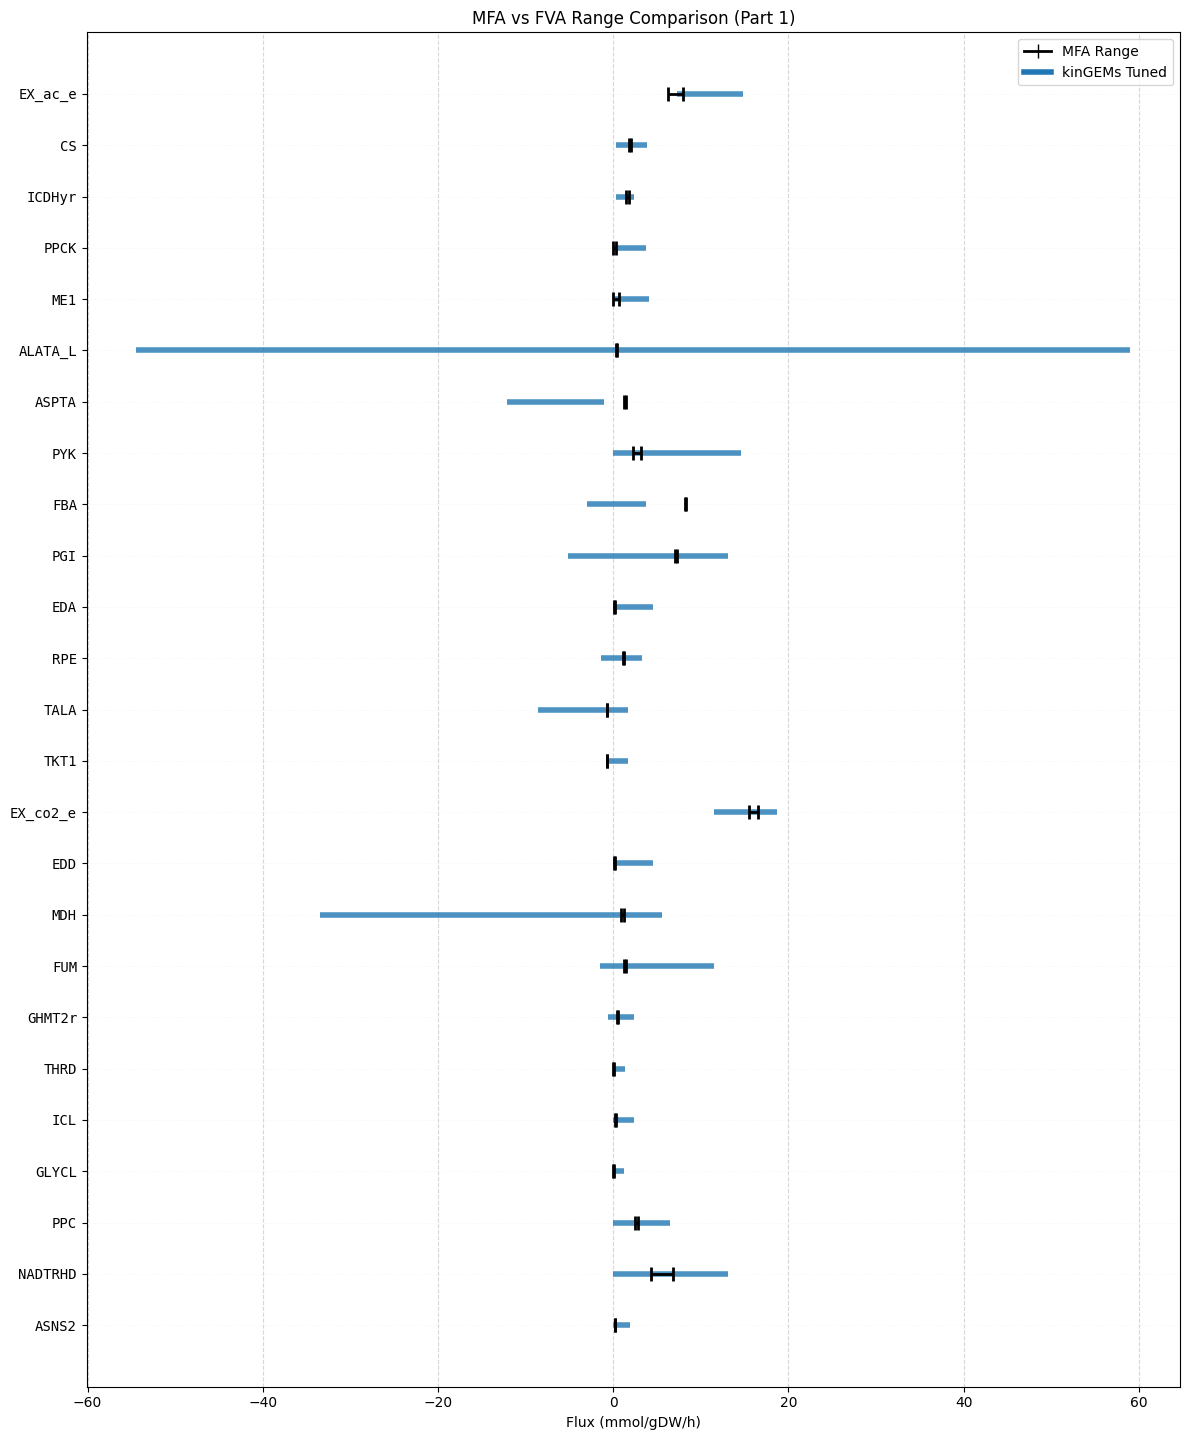

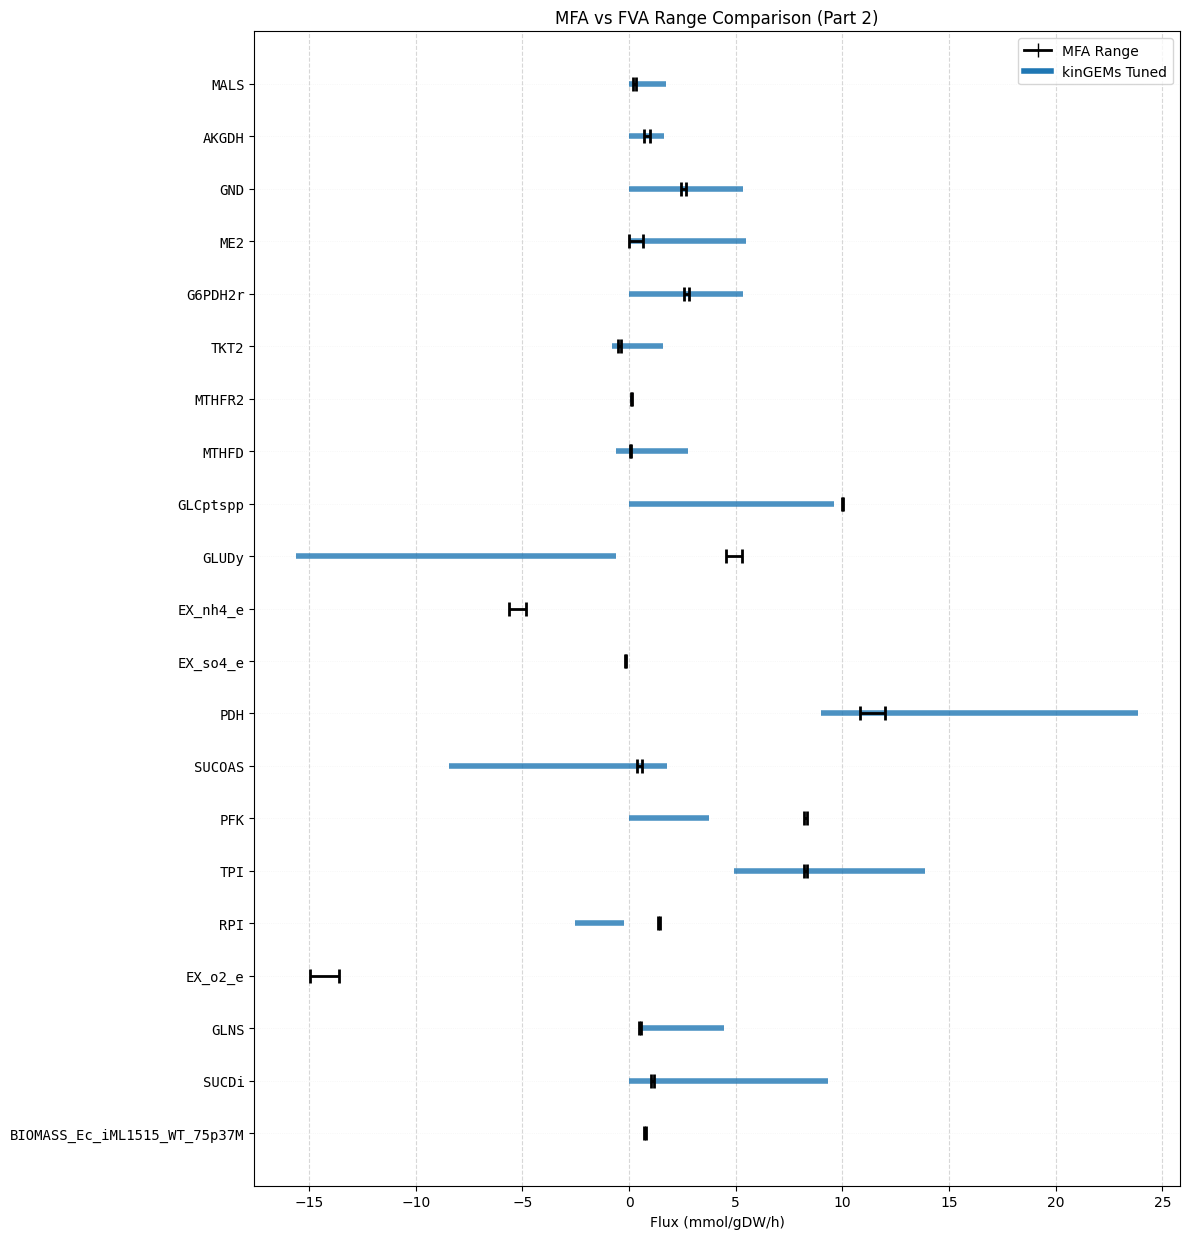

In [7]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva})